# ECON N171: Economic Development
## Lecture 7 — OLS Regression in Python
**Instructor: Rajveer Jat | Summer 2026**

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand OLS regression as a **minimization problem** and implement it manually
2. Run OLS using **statsmodels** — the standard Python econometrics library
3. **Read and interpret** a full regression output table
4. Run **multiple regression** and understand what controls do
5. Understand and test key **OLS assumptions** visually
6. Run **robust standard errors** — the default in applied economics

> Run each cell with Shift + Enter and follow along.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load the Gollin dataset from Lecture 6
# If not available, rebuild it here
try:
    df = pd.read_csv('gollin_data.csv')
    print('Loaded from file. Shape:', df.shape)
except FileNotFoundError:
    data = {
        'country'         : ['USA', 'France', 'Japan', 'South Korea', 'Australia',
                             'Brazil', 'Mexico', 'Colombia', 'Peru', 'Chile',
                             'China', 'Vietnam', 'Indonesia', 'Philippines', 'Thailand',
                             'Morocco', 'Egypt', 'Kenya', 'Ghana', 'Nigeria',
                             'Ethiopia', 'Rwanda', 'Tanzania', 'Mozambique', 'Nepal'],
        'region'          : ['High Income', 'High Income', 'High Income', 'High Income', 'High Income',
                             'Latin America', 'Latin America', 'Latin America', 'Latin America', 'Latin America',
                             'East Asia', 'East Asia', 'East Asia', 'East Asia', 'East Asia',
                             'MENA', 'MENA', 'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa',
                             'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa', 'Sub-Saharan Africa',
                             'Indian Subcontinent'],
        'gdp_pc'          : [42516, 29862, 30447, 24454, 35835,
                              8532,  9524,  7304,  6573, 13185,
                              6186,  2785,  3748,  3478,  7574,
                              3877,  5680,  1638,  1835,  2242,
                               864,   839,  1284,   735,  1040],
        'ag_share_emp'    : [1.5,  2.8,  3.7,  6.4,  3.2,
                             15.7, 13.4, 16.8, 25.7,  9.8,
                             36.7, 47.3, 38.9, 32.1, 32.5,
                             39.1, 27.8, 54.2, 44.7, 35.3,
                             72.8, 75.3, 66.1, 73.2, 65.8],
        'ag_share_gdp'    : [1.1,  1.7,  1.2,  2.5,  2.6,
                              5.5,  3.9,  8.1,  7.9,  3.7,
                             10.6, 18.4, 14.4, 10.9, 12.8,
                             14.0, 11.7, 29.5, 22.7, 21.9,
                             41.5, 31.7, 31.3, 25.6, 35.1],
        'ag_income_pc'    : [28420, 18500, 14200, 11800, 22100,
                              4820,  5310,  3640,  2870,  6920,
                              2510,  1340,  1620,  1490,  3280,
                              1820,  2640,   610,   740,   890,
                               320,   280,   490,   245,   390],
        'nonag_income_pc' : [48300, 33200, 34800, 28400, 40100,
                             11200, 12800,  9800,  9400, 15900,
                              9300,  5100,  6200,  5800, 11400,
                              5900,  7800,  3200,  3600,  4100,
                              2400,  2100,  2900,  1800,  2700],
        'literacy_rate'   : [99.0, 99.0, 99.0, 99.0, 99.0,
                             93.2, 95.2, 94.7, 94.5, 96.4,
                             95.9, 95.8, 95.4, 98.2, 93.8,
                             73.8, 73.1, 82.0, 79.0, 62.0,
                             52.1, 73.2, 78.4, 58.8, 67.9],
        'urbanization'    : [82.3, 81.0, 91.7, 81.4, 86.1,
                             86.3, 80.2, 81.0, 78.1, 87.8,
                             59.6, 37.3, 56.4, 47.4, 50.4,
                             63.5, 43.1, 28.0, 57.4, 52.0,
                             21.7, 17.4, 35.2, 37.1, 20.6]
    }
    df = pd.DataFrame(data)
    df['ag_gap']  = df['nonag_income_pc'] / df['ag_income_pc']
    df['log_gdp'] = np.log(df['gdp_pc'])
    df['log_gap'] = np.log(df['ag_gap'])
    print('Rebuilt dataset. Shape:', df.shape)

df.head()

Rebuilt dataset. Shape: (25, 12)


,country,region,gdp_pc,ag_share_emp,ag_share_gdp,ag_income_pc,nonag_income_pc,literacy_rate,urbanization,ag_gap,log_gdp,log_gap
0,USA,High Income,42516,1.5,1.1,28420,48300,99.0,82.3,1.699507,10.657636,0.530338
1,France,High Income,29862,2.8,1.7,18500,33200,99.0,81.0,1.794595,10.304342,0.584779
2,Japan,High Income,30447,3.7,1.2,14200,34800,99.0,91.7,2.450704,10.323743,0.896375
3,South Korea,High Income,24454,6.4,2.5,11800,28400,99.0,81.4,2.406780,10.104549,0.878290
4,Australia,High Income,35835,3.2,2.6,22100,40100,99.0,86.1,1.814480,10.486680,0.595799


---
## Part 1: What OLS Does — From Scratch

OLS finds the line that **minimizes the sum of squared residuals**.

$$\hat{\beta} = \arg\min_{\beta} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2$$

The closed-form solution is:

$$\hat{\beta} = (X'X)^{-1} X'y$$

We already implemented this in Lecture 2 using NumPy. Now let's see it visually.

In [5]:
# Visualize what OLS minimizes
x = df['log_gdp'].values
y = df['ag_gap'].values

# Compute OLS manually
X = np.column_stack([np.ones(len(x)), x])
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta0, beta1 = beta
y_hat = beta0 + beta1 * x
residuals = y - y_hat

print(f'OLS coefficients (manual):')
print(f'  Intercept (beta_0): {beta0:.4f}')
print(f'  Slope     (beta_1): {beta1:.4f}')
print()
print(f'If X increases by 1% → log(X) increases by ≈ 0.01')
print(f'with a {0.01*beta1:.4f} unit change in agricultural gap.')

OLS coefficients (manual):
  Intercept (beta_0): 15.6862
  Slope     (beta_1): -1.3813

If X increases by 1% → log(X) increases by ≈ 0.01
with a -0.0138 unit change in agricultural gap.


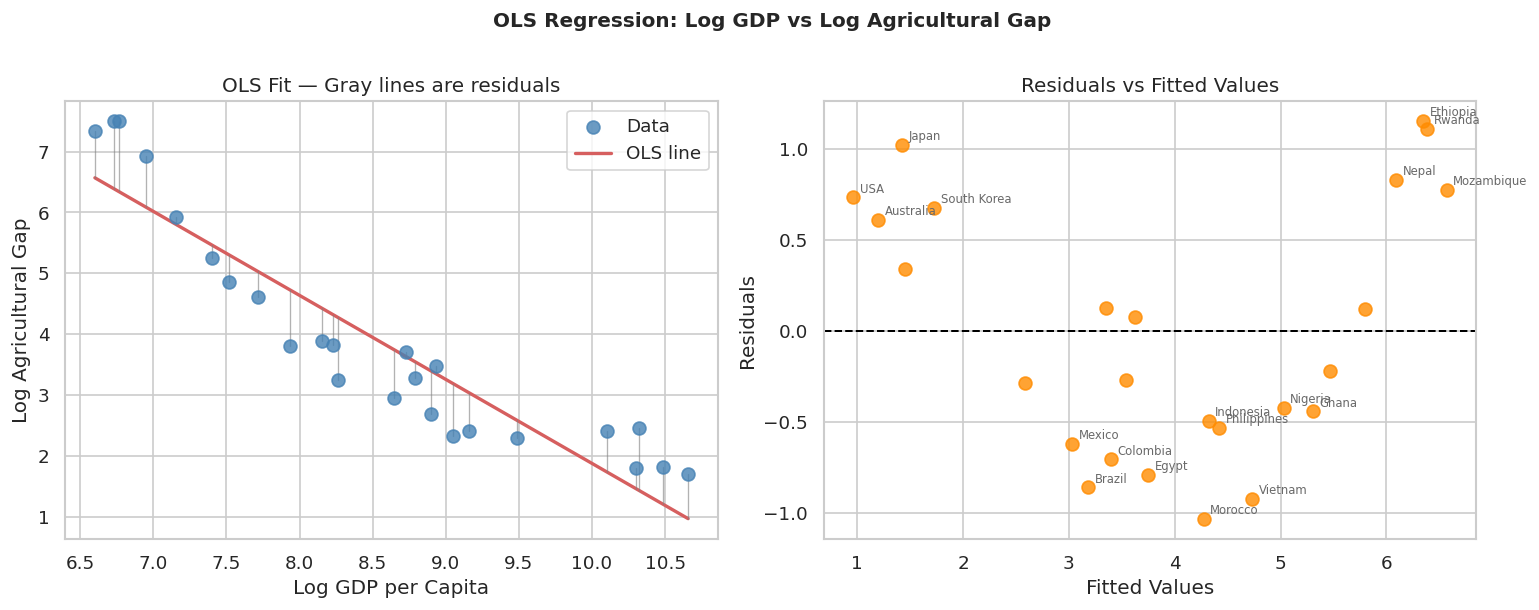

In [6]:
# Plot the OLS fit with residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter + OLS line + residuals
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].scatter(x, y, color='steelblue', s=60, alpha=0.8, zorder=3, label='Data')
axes[0].plot(x_line, beta0 + beta1 * x_line, 'r-', linewidth=2, label='OLS line')

# Draw residuals as vertical lines
for xi, yi, yi_hat in zip(x, y, y_hat):
    axes[0].plot([xi, xi], [yi_hat, yi], color='gray', linewidth=0.8, alpha=0.6)

axes[0].set_xlabel('Log GDP per Capita')
axes[0].set_ylabel('Log Agricultural Gap')
axes[0].set_title('OLS Fit — Gray lines are residuals')
axes[0].legend()

# Right: residuals plot
axes[1].scatter(y_hat, residuals, color='darkorange', s=60, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
for i, (yi_hat, res) in enumerate(zip(y_hat, residuals)):
    if abs(res) > 0.4:
        axes[1].annotate(df['country'].iloc[i],
                         (yi_hat, res), fontsize=7,
                         xytext=(4, 3), textcoords='offset points', color='dimgray')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted Values')

plt.suptitle('OLS Regression: Log GDP vs Log Agricultural Gap',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2: OLS with Statsmodels — The Standard Tool

In [7]:
# Simple regression: log_gap ~ log_gdp
# statsmodels formula API — reads like R
model1 = smf.ols('log_gap ~ log_gdp', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                log_gap   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     297.6
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           1.18e-14
Time:                        02:39:59   Log-Likelihood:                 17.364
No. Observations:                  25   AIC:                            -30.73
Df Residuals:                      23   BIC:                            -28.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2937      0.177     24.192      0.0

### Reading the Output Table

| Output | What it means |
|--------|---------------|
| **coef** | The estimated slope or intercept |
| **std err** | Standard error — uncertainty in the estimate |
| **t** | t-statistic = coef / std err |
| **P>|t|** | p-value — probability of seeing this coef if true effect is zero |
| **[0.025, 0.975]** | 95% confidence interval |
| **R-squared** | Share of variance in y explained by x |
| **F-statistic** | Joint significance of all regressors |

In [8]:
# Extract key results cleanly
print('=== Simple Regression: log_gap ~ log_gdp ===')
print(f'  Intercept:  {model1.params["Intercept"]:>8.4f}  (p={model1.pvalues["Intercept"]:.4f})')
print(f'  log_gdp:    {model1.params["log_gdp"]:>8.4f}  (p={model1.pvalues["log_gdp"]:.4f})')
print(f'  R-squared:  {model1.rsquared:>8.4f}')
print(f'  N:          {int(model1.nobs):>8d}')
print()
print('Interpretation:')
print(f'  A 1 unit increase in log GDP per capita is associated with a')
print(f'  {model1.params["log_gdp"]:.4f} unit change in log agricultural gap.')
print(f'  This is statistically significant at the 1% level (p < 0.01).')

=== Simple Regression: log_gap ~ log_gdp ===
  Intercept:    4.2937  (p=0.0000)
  log_gdp:     -0.3558  (p=0.0000)
  R-squared:    0.9283
  N:                25

Interpretation:
  A 1 unit increase in log GDP per capita is associated with a
  -0.3558 unit change in log agricultural gap.
  This is statistically significant at the 1% level (p < 0.01).


---
## Part 3: Multiple Regression — Adding Controls

In [9]:
# Model 2: add agricultural employment share
model2 = smf.ols('log_gap ~ log_gdp + ag_share_emp', data=df).fit()

# Model 3: add literacy and urbanization
model3 = smf.ols('log_gap ~ log_gdp + ag_share_emp + literacy_rate + urbanization',
                  data=df).fit()

# Model 4: region fixed effects (dummies)
model4 = smf.ols('log_gap ~ log_gdp + ag_share_emp + literacy_rate + C(region)',
                  data=df).fit()

print('Model 2 R-squared:', round(model2.rsquared, 4))
print('Model 3 R-squared:', round(model3.rsquared, 4))
print('Model 4 R-squared:', round(model4.rsquared, 4))

Model 2 R-squared: 0.9555
Model 3 R-squared: 0.956
Model 4 R-squared: 0.9728


In [10]:
# Regression table — comparing all models side by side
# This is the standard format in academic papers
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [model1, model2, model3, model4],
    model_names=['(1)', '(2)', '(3)', '(4)'],
    stars=True,
    float_format='%.3f',
    info_dict={
        'N'         : lambda x: f'{int(x.nobs)}',
        'R-squared' : lambda x: f'{x.rsquared:.3f}'
    }
)
print('Dependent variable: Log Agricultural Productivity Gap')
print(table)

Dependent variable: Log Agricultural Productivity Gap

                                    (1)      (2)      (3)      (4)  
--------------------------------------------------------------------
Intercept                        4.294***  2.026*** 2.079*** 2.773**
                                 (0.177)   (0.635)  (0.720)  (1.048)
log_gdp                          -0.356*** -0.136** -0.128*  -0.174 
                                 (0.021)   (0.062)  (0.068)  (0.110)
ag_share_emp                               0.012*** 0.011**  0.008* 
                                           (0.003)  (0.004)  (0.004)
literacy_rate                                       -0.001   -0.003 
                                                    (0.002)  (0.003)
urbanization                                        -0.000          
                                                    (0.002)         
C(region)[T.High Income]                                     -0.010 
                                                

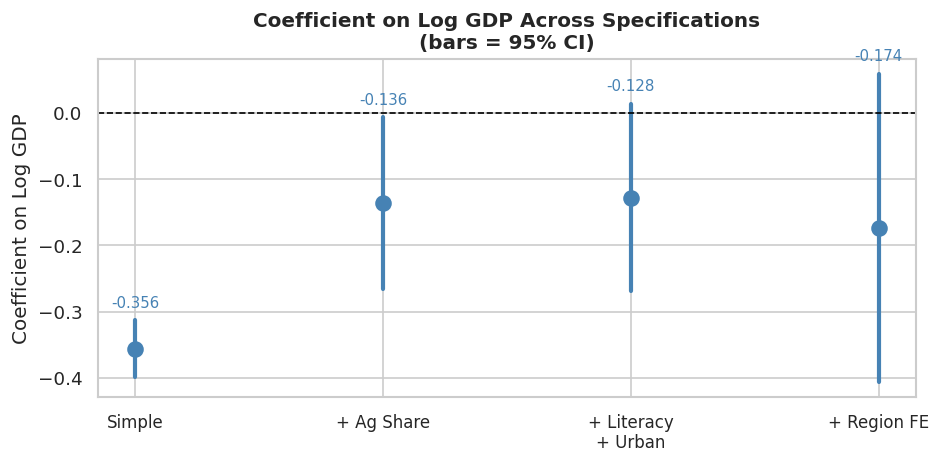

In [11]:
# Visualize: how does the log_gdp coefficient change as we add controls?
models      = [model1, model2, model3, model4]
model_names = ['Simple', '+ Ag Share', '+ Literacy\n+ Urban', '+ Region FE']
coefs       = [m.params['log_gdp'] for m in models]
cis         = [(m.conf_int().loc['log_gdp', 0], m.conf_int().loc['log_gdp', 1]) for m in models]

fig, ax = plt.subplots(figsize=(8, 4))

for i, (coef, (lo, hi), name) in enumerate(zip(coefs, cis, model_names)):
    ax.plot([i, i], [lo, hi], color='steelblue', linewidth=2.5)
    ax.scatter(i, coef, color='steelblue', s=80, zorder=5)
    ax.text(i, hi + 0.02, f'{coef:.3f}', ha='center', fontsize=9, color='steelblue')

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Coefficient on Log GDP')
ax.set_title('Coefficient on Log GDP Across Specifications\n(bars = 95% CI)',
             fontweight='bold')

plt.tight_layout()
plt.show()

---
## Part 4: OLS Assumptions — Visual Diagnostics

OLS is BLUE (Best Linear Unbiased Estimator) under the Gauss-Markov assumptions.
We check the most important ones visually.

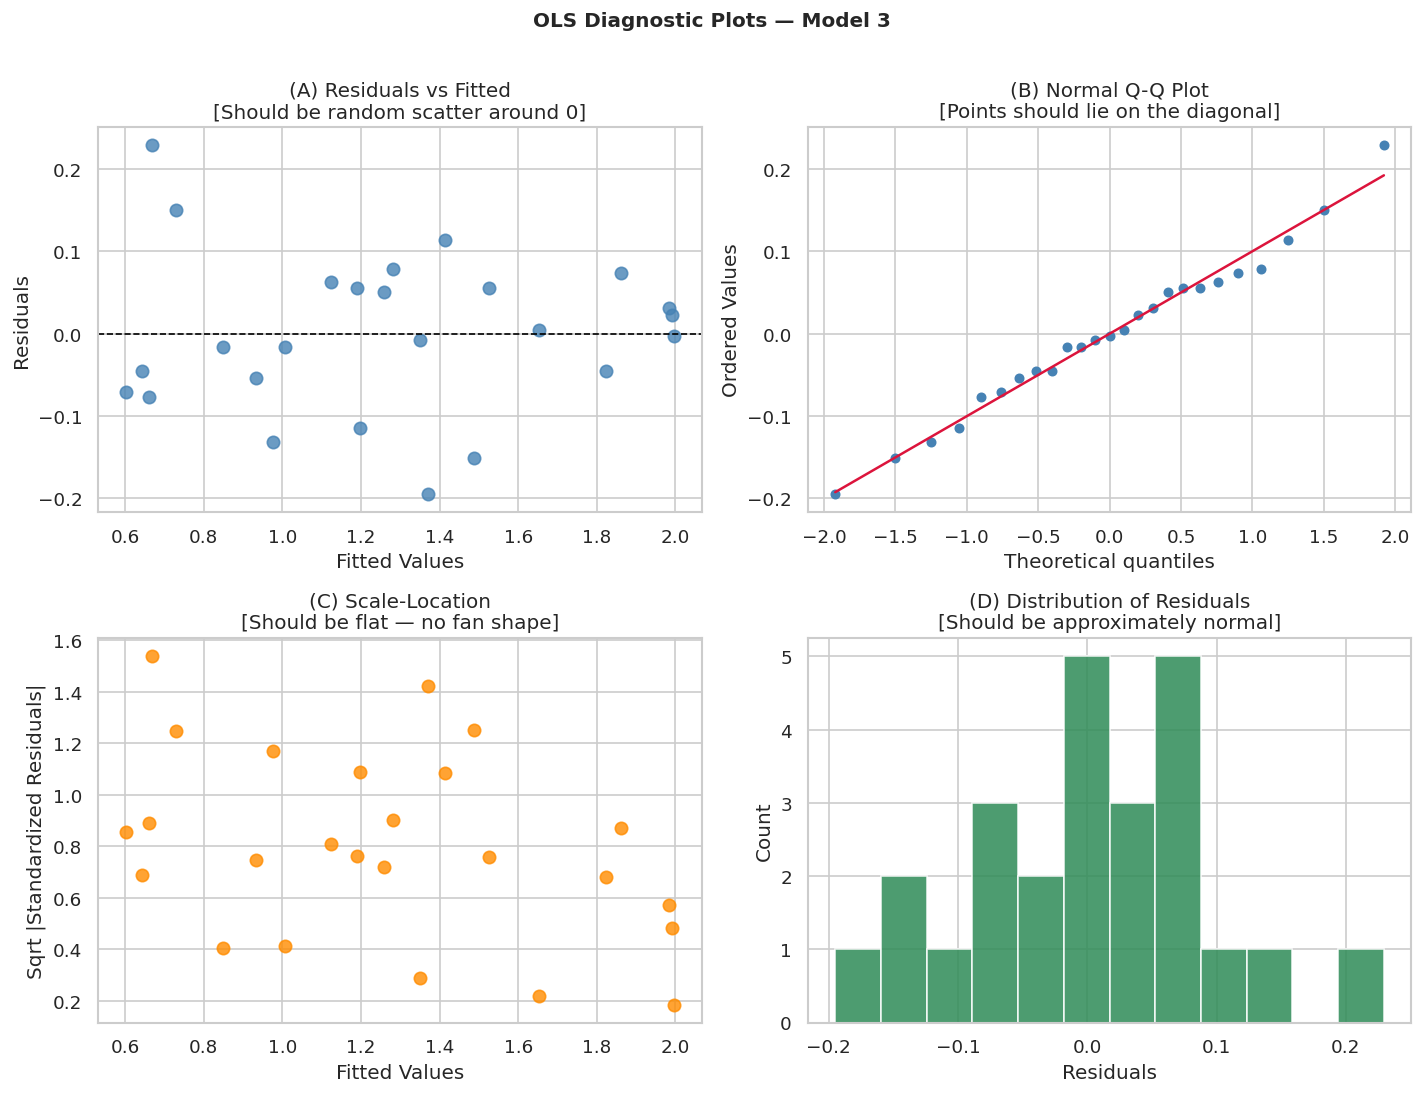

In [12]:
fitted    = model3.fittedvalues
residuals = model3.resid
std_resid = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Panel A: Residuals vs Fitted — check linearity and homoskedasticity
axes[0,0].scatter(fitted, residuals, color='steelblue', s=55, alpha=0.8)
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('(A) Residuals vs Fitted\n[Should be random scatter around 0]')

# Panel B: QQ plot — check normality of residuals
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].set_title('(B) Normal Q-Q Plot\n[Points should lie on the diagonal]')
axes[0,1].get_lines()[0].set(color='steelblue', markersize=5)
axes[0,1].get_lines()[1].set(color='crimson', linewidth=1.5)

# Panel C: Scale-Location — check homoskedasticity
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_resid)), color='darkorange', s=55, alpha=0.8)
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('Sqrt |Standardized Residuals|')
axes[1,0].set_title('(C) Scale-Location\n[Should be flat — no fan shape]')

# Panel D: Residuals distribution
axes[1,1].hist(residuals, bins=12, color='seagreen', edgecolor='white', alpha=0.85)
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('(D) Distribution of Residuals\n[Should be approximately normal]')

plt.suptitle('OLS Diagnostic Plots — Model 3', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 5: Robust Standard Errors

In cross-country regressions, **heteroskedasticity** is nearly always present —
the variance of residuals is not constant across observations.
The fix: **heteroskedasticity-robust standard errors** (HC1), the default in applied economics.

In [13]:
# Fit model with robust standard errors
model3_robust = smf.ols(
    'log_gap ~ log_gdp + ag_share_emp + literacy_rate + urbanization',
    data=df
).fit(cov_type='HC1')

print('=== Model 3: Standard vs Robust SEs ===')
print(f'{"Variable":<20} {"Coef":>8} {"SE (OLS)":>12} {"SE (Robust)":>12} {"p (OLS)":>10} {"p (Robust)":>12}')
print('-' * 76)
for var in model3.params.index:
    coef    = model3.params[var]
    se_ols  = model3.bse[var]
    se_rob  = model3_robust.bse[var]
    p_ols   = model3.pvalues[var]
    p_rob   = model3_robust.pvalues[var]
    print(f'{var:<20} {coef:>8.4f} {se_ols:>12.4f} {se_rob:>12.4f} {p_ols:>10.4f} {p_rob:>12.4f}')

=== Model 3: Standard vs Robust SEs ===
Variable                 Coef     SE (OLS)  SE (Robust)    p (OLS)   p (Robust)
----------------------------------------------------------------------------
Intercept              2.0791       0.7205       0.7345     0.0091       0.0046
log_gdp               -0.1280       0.0677       0.0637     0.0731       0.0445
ag_share_emp           0.0115       0.0042       0.0042     0.0130       0.0059
literacy_rate         -0.0011       0.0024       0.0025     0.6396       0.6505
urbanization          -0.0002       0.0024       0.0025     0.9287       0.9313


---
## Part 6: Prediction and Residual Analysis

In [14]:
# Add fitted values and residuals to the dataframe
df['fitted']   = model3.fittedvalues
df['residual'] = model3.resid

# Which countries does the model explain poorly?
df['abs_resid'] = df['residual'].abs()
print('Countries with largest residuals (model 3):')
df[['country', 'region', 'log_gap', 'fitted', 'residual']]\
    .sort_values('abs_resid', ascending=False)\
    .head(8)\
    .round(3)

Countries with largest residuals (model 3):


KeyError: 'abs_resid'

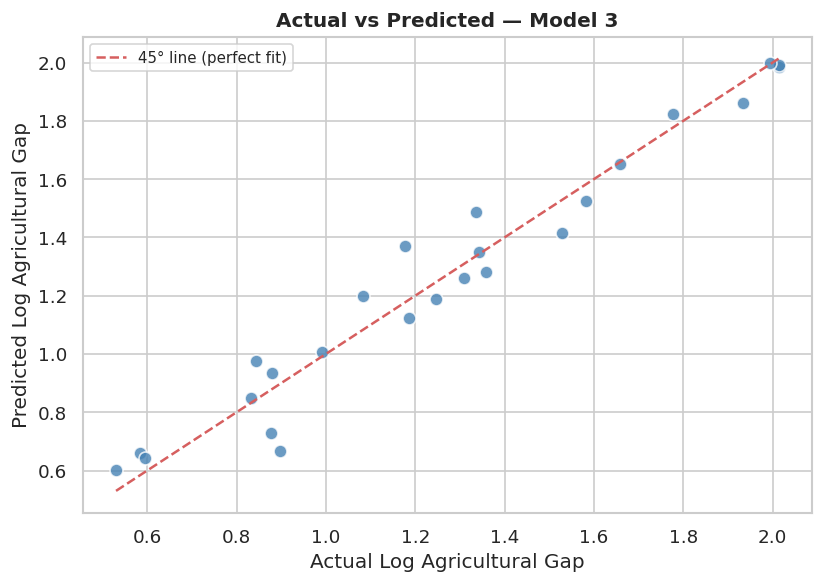

In [15]:
# Actual vs predicted plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df['log_gap'], df['fitted'],
           color='steelblue', s=60, alpha=0.8, edgecolors='white')

# 45-degree line = perfect prediction
lims = [min(df['log_gap'].min(), df['fitted'].min()),
        max(df['log_gap'].max(), df['fitted'].max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='45° line (perfect fit)')

for _, row in df.iterrows():
    if abs(row['residual']) > 0.35:
        ax.annotate(row['country'], (row['log_gap'], row['fitted']),
                    fontsize=7.5, xytext=(4, 3),
                    textcoords='offset points', color='dimgray')

ax.set_xlabel('Actual Log Agricultural Gap')
ax.set_ylabel('Predicted Log Agricultural Gap')
ax.set_title('Actual vs Predicted — Model 3', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 7: Hypothesis Testing

The three questions you always ask in applied economics:
1. Is this coefficient zero? (t-test)
2. Are all coefficients jointly zero? (F-test)
3. Is the coefficient equal to a specific value? (Wald test)

In [16]:
# t-test: is the log_gdp coefficient significantly different from zero?
coef    = model3.params['log_gdp']
se      = model3.bse['log_gdp']
t_stat  = coef / se
p_value = model3.pvalues['log_gdp']

print('=== t-test: H0: beta_log_gdp = 0 ===')
print(f'  Coefficient: {coef:.4f}')
print(f'  Std Error:   {se:.4f}')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_value:.6f}')
print()
if p_value < 0.01:
    print('  -> Reject H0 at 1% significance level.')
elif p_value < 0.05:
    print('  -> Reject H0 at 5% significance level.')
else:
    print('  -> Fail to reject H0.')

=== t-test: H0: beta_log_gdp = 0 ===
  Coefficient: -0.1280
  Std Error:   0.0677
  t-statistic: -1.8916
  p-value:     0.073118

  -> Fail to reject H0.


In [17]:
# F-test: are ag_share_emp and literacy jointly significant?
f_test = model3.f_test(['ag_share_emp = 0', 'literacy_rate = 0'])
print('=== F-test: H0: beta_ag_share_emp = beta_literacy = 0 ===')
print(f'  F-statistic: {f_test.fvalue[0][0]:.4f}')
print(f'  p-value:     {f_test.pvalue:.6f}')
if f_test.pvalue < 0.05:
    print('  -> Jointly significant at 5% level.')
else:
    print('  -> Fail to reject joint null.')

=== F-test: H0: beta_ag_share_emp = beta_literacy = 0 ===


TypeError: 'float' object is not subscriptable

In [18]:
# Wald test: is beta_log_gdp = -1 (unit elasticity)?
wald = model3.f_test('log_gdp = -1')
print('=== Wald test: H0: beta_log_gdp = -1 ===')
print(f'  F-statistic: {wald.fvalue[0][0]:.4f}')
print(f'  p-value:     {wald.pvalue:.6f}')
if wald.pvalue < 0.05:
    print('  -> Reject H0: the elasticity is not -1.')
else:
    print('  -> Fail to reject H0: consistent with unit elasticity.')

=== Wald test: H0: beta_log_gdp = -1 ===


TypeError: 'float' object is not subscriptable

---
## Summary

| Task | Code |
|------|------|
| Simple OLS | `smf.ols('y ~ x', data=df).fit()` |
| Multiple OLS | `smf.ols('y ~ x1 + x2 + x3', data=df).fit()` |
| Region dummies | `smf.ols('y ~ x + C(region)', data=df).fit()` |
| Robust SEs | `.fit(cov_type='HC1')` |
| Full output | `model.summary()` |
| Extract coef | `model.params['x']` |
| Extract p-value | `model.pvalues['x']` |
| Confidence interval | `model.conf_int()` |
| Fitted values | `model.fittedvalues` |
| Residuals | `model.resid` |
| t-test | `model.pvalues['x']` |
| F-test / Wald test | `model.f_test(...)` |
| Compare models | `summary_col([m1, m2, m3])` |

**Next lecture:** Phase 2 begins — replicating your JDE paper using nonparametric estimation in Python.

---
*ECON N171 | Summer 2026*